# Archetypal Analysis (AA) on human hematopoietic stem cell (HSC) dataset
This notebook applies AA on the HSC scRNA+ATAC dataset. Prior to this analysis, data should be processed correctly and contained within processed_data/ folder. See 1_Data_preparation.ipynb for details.

In [1]:
import numpy as np
import pandas as pd

In [2]:
import os

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import ArchVelo as av

In [5]:
import scanpy as sc

In [6]:
data_outdir = 'processed_data/'
model_outdir = 'modeling_results/'
outdir = model_outdir+'archetypes/'
os.makedirs(outdir, exist_ok = True)

In [7]:
num_comps = 9

In [8]:
fig_outdir = 'figures/'
os.makedirs(fig_outdir, exist_ok = True)


# Read in data

In [14]:
# preprocessed ATAC for ArchVelo
atac = sc.read_h5ad(data_outdir+'adata_atac_raw.h5ad')

In [11]:
rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [ ]:
XC, S = av.apply_AA_no_test(atac, 
                  k = num_comps,
                  outdir = outdir,
                  )

In [9]:
XC = pd.read_csv(outdir+'cell_on_peaks_'+str(num_comps)+'_comps.csv', index_col = [0])

In [12]:
rna.obs[['A_'+str(i) for i in range(num_comps)]] = XC.values

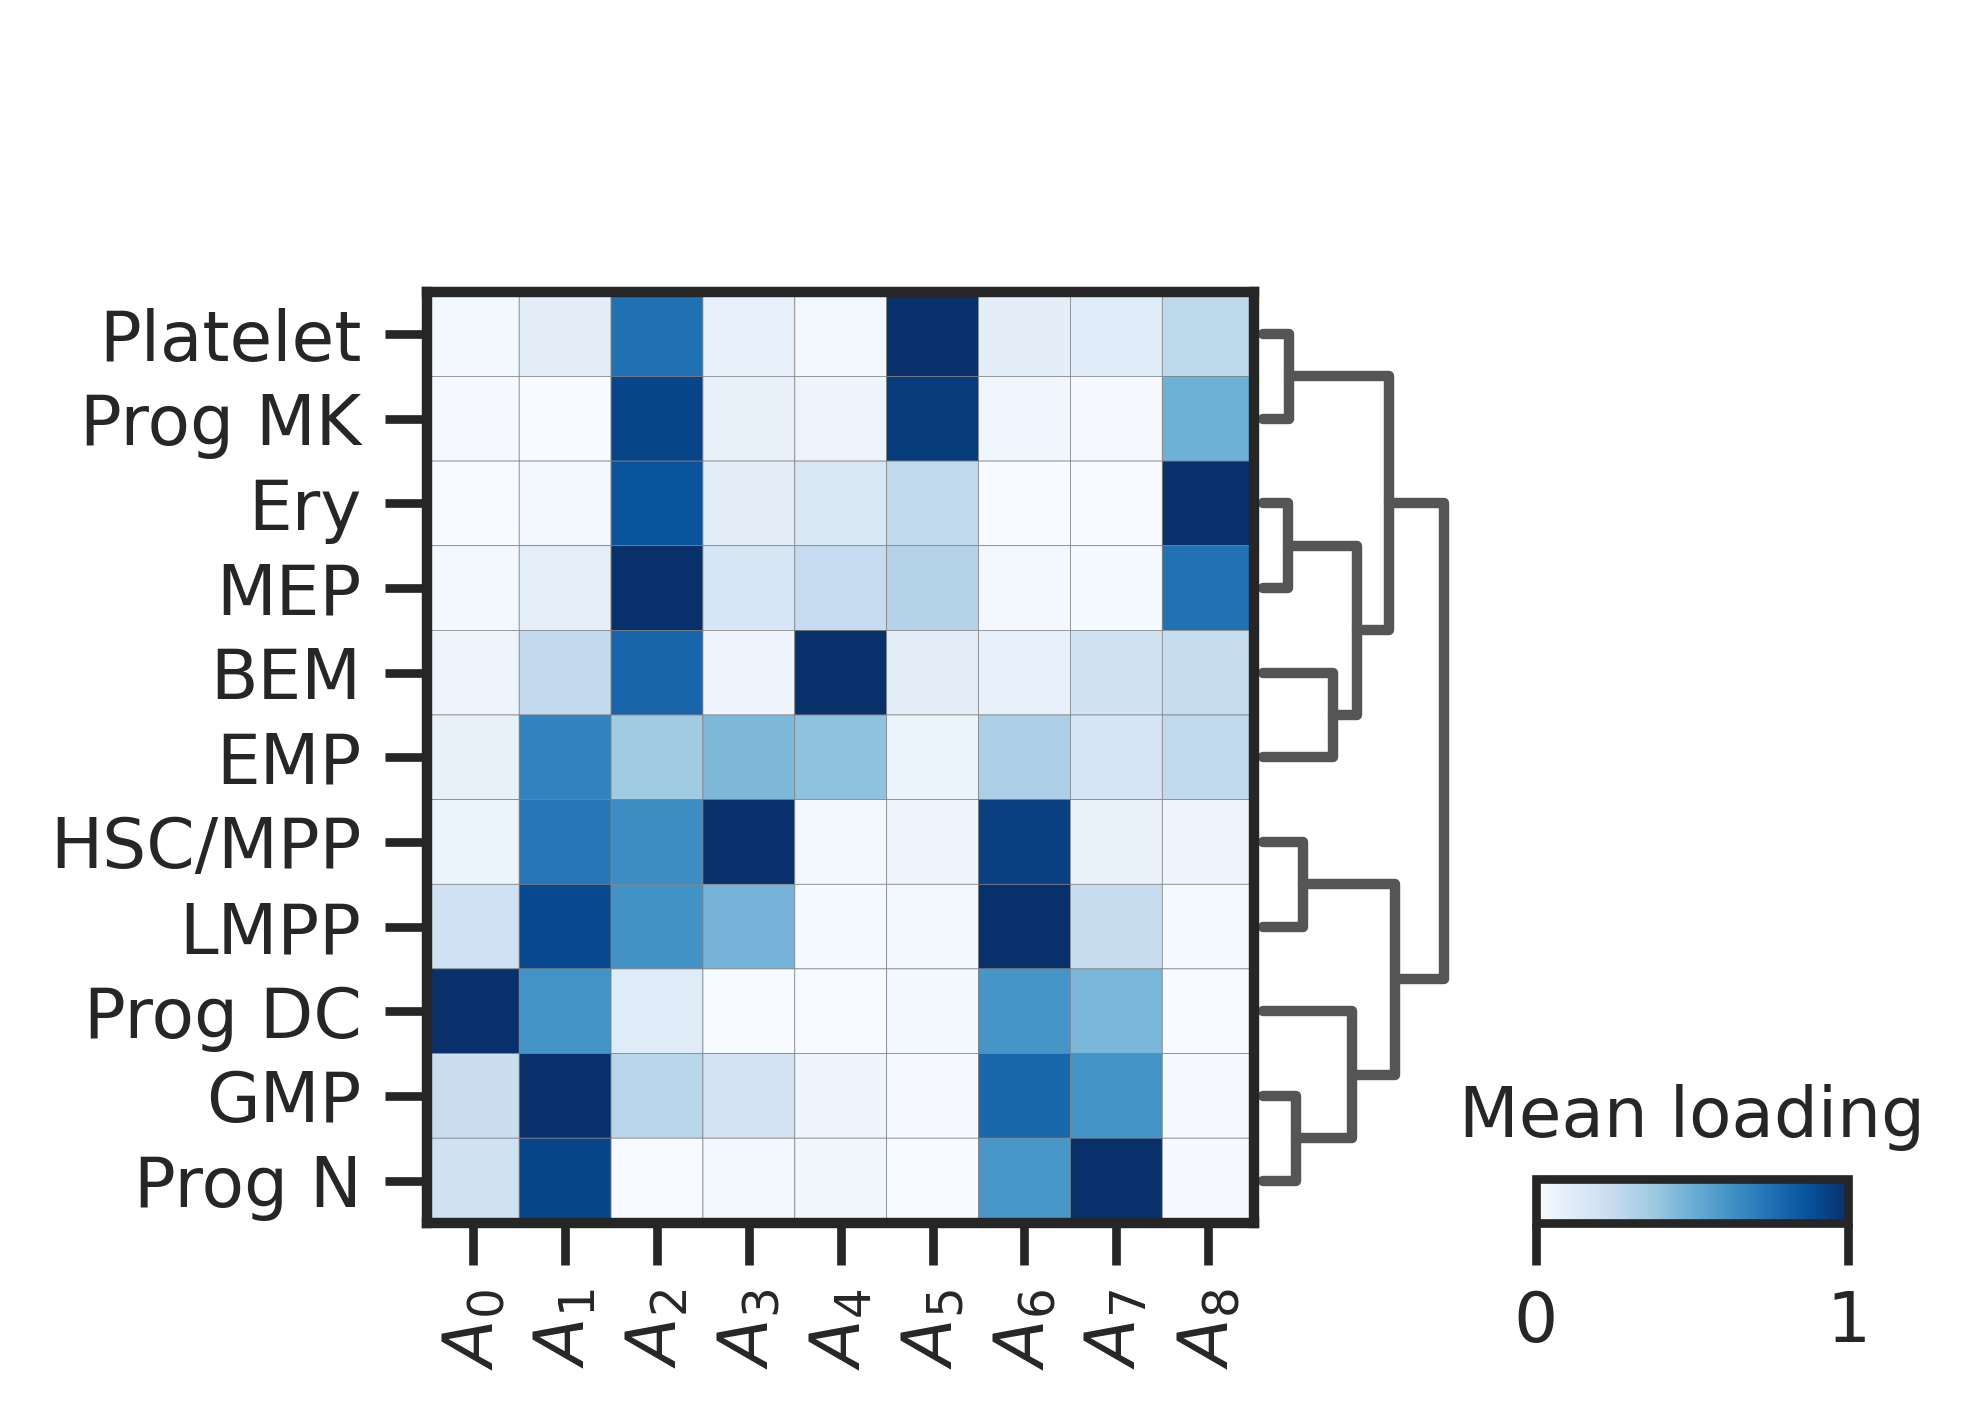

In [13]:
# 9 comps
sns.set(style = 'ticks', font_scale = 1.)
fig, ax = plt.subplots(1,1,dpi = 500, figsize = (4,3))
g = sc.pl.matrixplot(rna, ['A_'+str(i) for i in range(num_comps)],
                     groupby = 'cell_type', 
                     standard_scale = 'var', 
                     #return_fig=True,
                     show = False,
                     dendrogram = True, cmap = 'Blues', swap_axes = False,
                     ax = ax,
                     colorbar_title = 'Mean loading')
g['mainplot_ax'].set_xticks(np.arange(0,num_comps)+0.5, ['$A_'+str(i)+'$' for i in range(num_comps)])
plt.tight_layout()
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.png', dpi = 600)
fig.savefig(fig_outdir+'Archetypes_per_celltype_rotated.svg', dpi = 600)